<a href="https://colab.research.google.com/github/Ethan2417/Pima-Indians-Diabetes-Prediction/blob/main/pima_diabetes_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Loading important liabraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading the Dataset
df = pd.read_csv("diabetes.csv")

In [3]:
#Glimpse of the Data
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
# Analyzing the first 10 rows first 10 rows
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [5]:
# Info of Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
#Total number of rows and columns
df.shape

(768, 9)

In [7]:
#Checking the datatypes & Basic Statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# checking is there any null value??
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
# Identify the invalid Zero values #Like Glucose, BMI & Insulin cannot be Zero. It means missing or not recorded.
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

(df[invalid_zero_cols] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [10]:
#Replacing Invalid Zeros with NaN (for analysis)
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

In [11]:
#Now checking the replaced values #now we can see As previously it was showing no null values, however currenntly we have the NUll values!
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


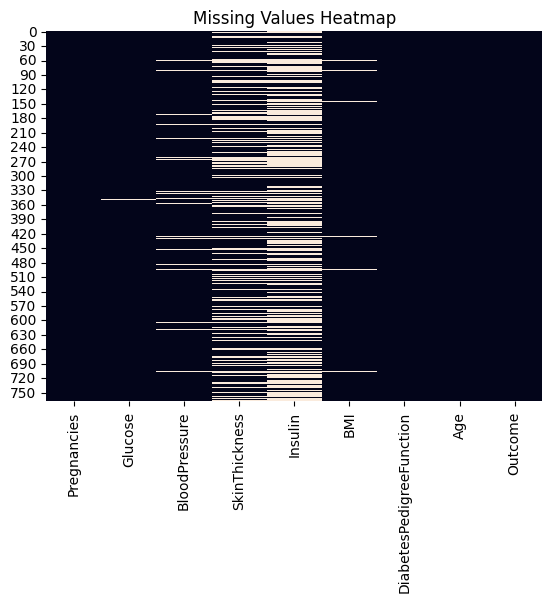

In [12]:
#Simply visualizing the missing values

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [13]:
#Target Variable Analysis(Outcome)
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


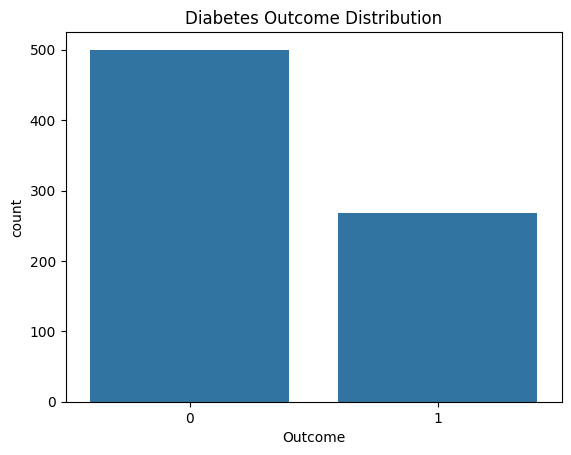

In [14]:
#Showing the Target Variable through visulization
sns.countplot(x ='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

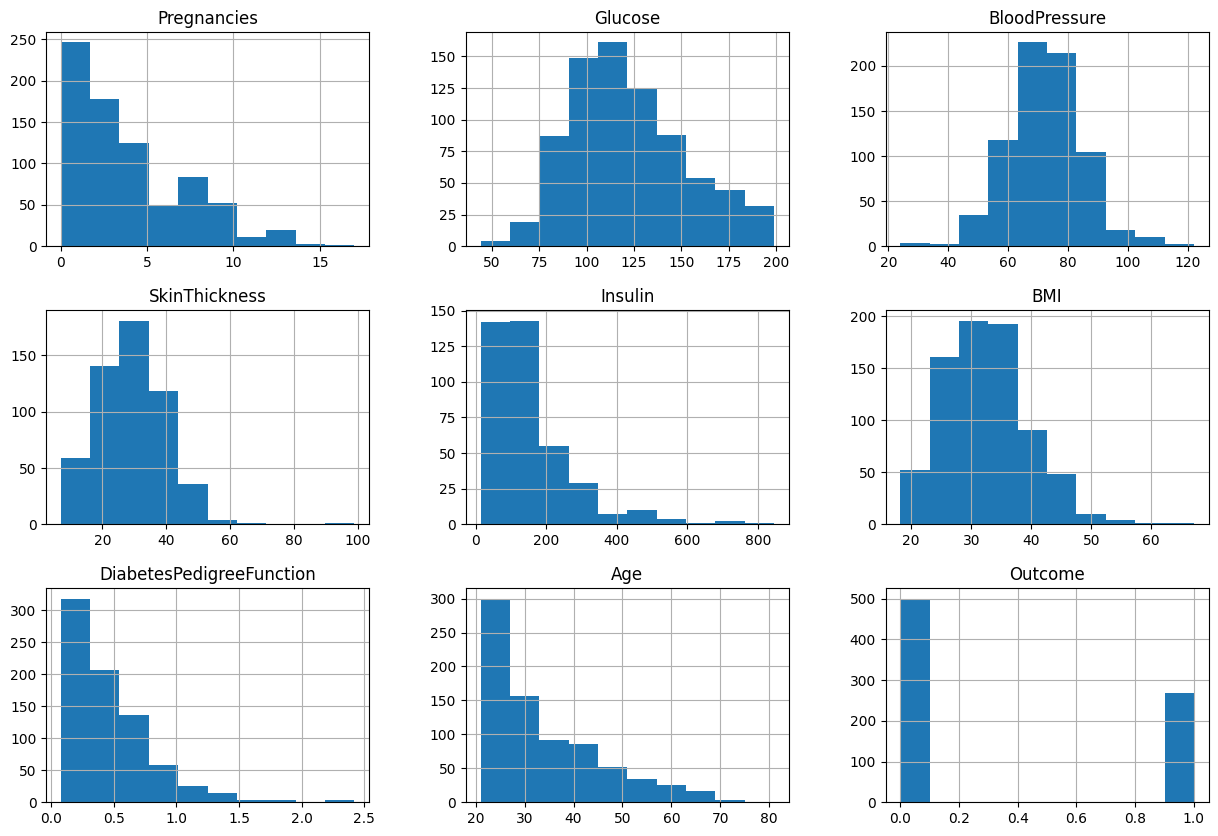

In [15]:
#Univariate Analysis(Feature Distributions)
#Univariate anallysis helps understand indiviual feature distribution, detect skewness and outliers, and guides preprocesssing decision before modeling.

df.hist(figsize=(15, 10))
plt.show()

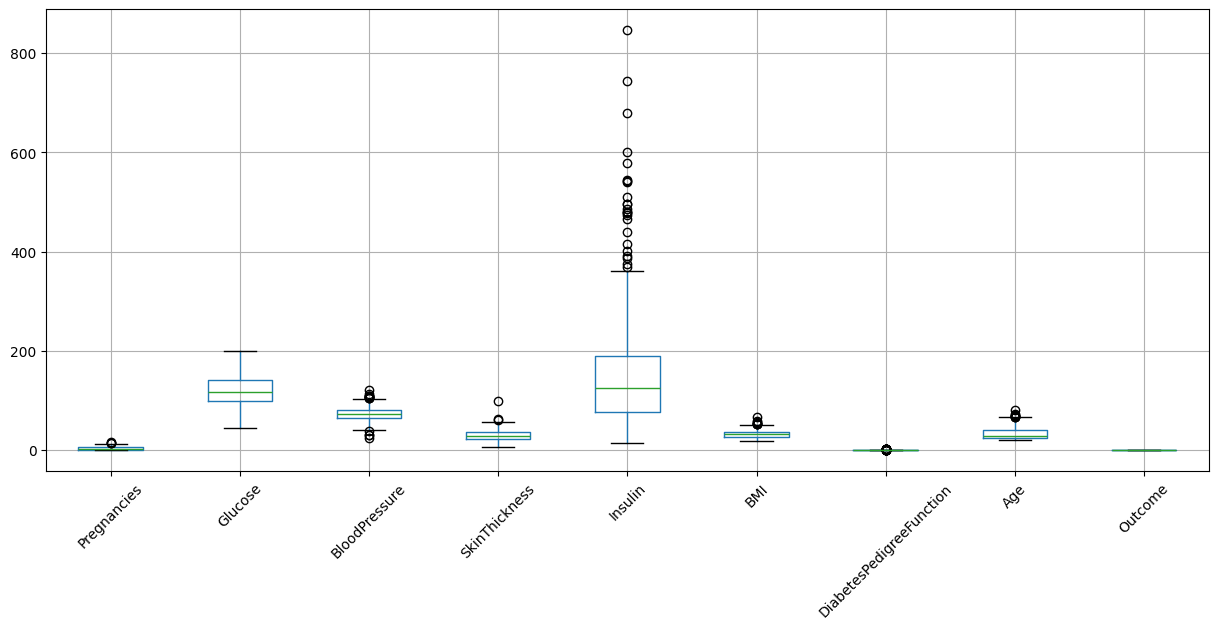

In [16]:
#Boxplots (Outlier Detection)
#Boxplot analysis revealed significant outlier and right-skewness in insulin and DiabetesPedigreeFunction, whie BMI showed moderate outliers. These findings justify the use of median-based
#imputation and feature scaling prior to model training.""
plt.figure(figsize=(15, 6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

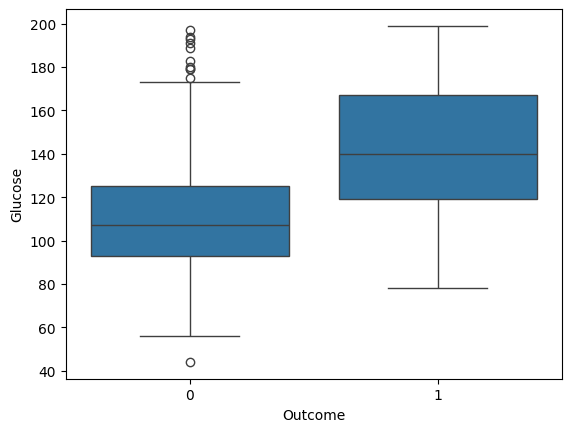

In [17]:
#Outcome vs Feature Relationships #Compare diabetics vs non-diabetics
#Outcome-wise boxplot analysis shows that diabetic patients exhibit significantly higher glucose levels compared to non-diabetic patients, indicating glucose as a strong discriminative feature.
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.show()

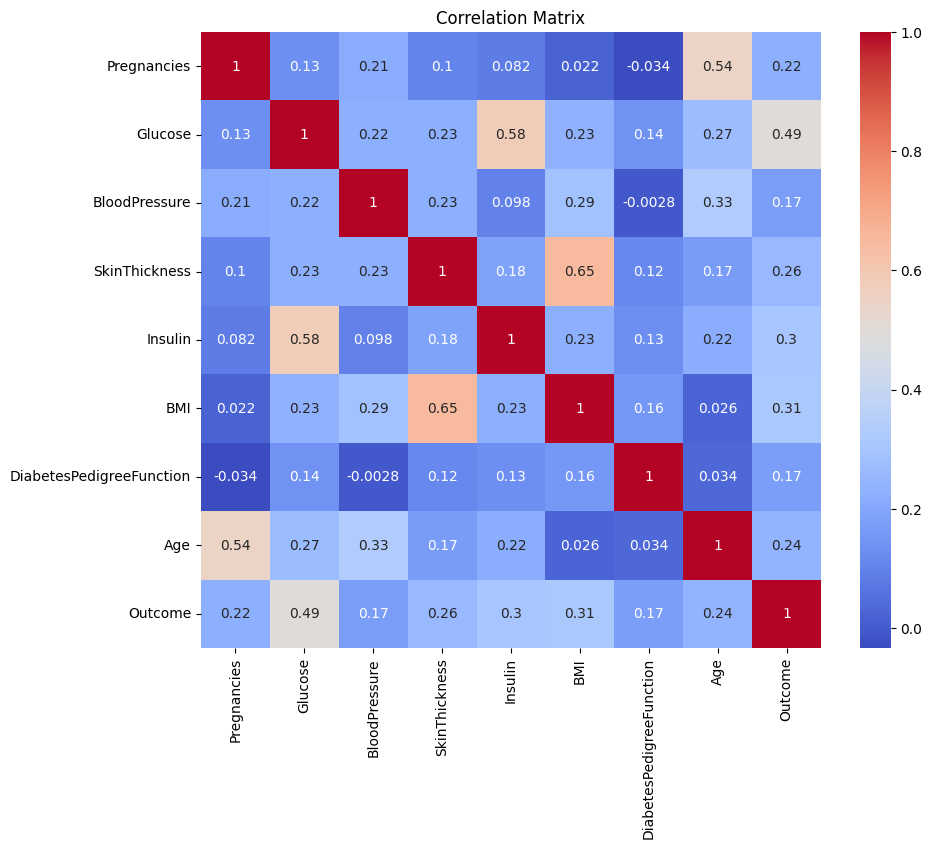

In [18]:
#Correlation Analysis
#Correlation analysis shows that Glucose has the strongest linear relationship with diabetes outcome, followed by BMI and Insulin. Moderate inter-feature correlations exist but are not severe enough to cause multicollinearity issues.
plt.figure(figsize =(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
#Imputation Strategy #After analysis filled missing values;

df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].median())

In [20]:
#Assesing the missing value
#Missing values arising from invalid zero entries were imputed using median values to preserve distribution robustness. Post-imputation checks confirmed the absence of missing data.
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [21]:
#Train & Test Split
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1) #Since X is the input feature so Target should be removed, axis = 1 asked the model to keep the data as it is after removing Outcome
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
#Feature Scaling (Standardization)
#Scale features before training the Logistic Regression and LDA models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [23]:
#Train and Test Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize model
log_reg = LogisticRegression(max_iter=1000)

#Train model
log_reg.fit(X_train_scaled, y_train)

#Predict on training data
y_train_pred = log_reg.predict(X_train_scaled)

#Predict on test data
y_test_pred = log_reg.predict(X_test_scaled)

#training_accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

#Test Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Cnfusion Matrix Test Data
print("\nConfusion Matrix (Test Data):")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 0.7964169381107492
Test Accuracy: 0.7077922077922078

Confusion Matrix (Test Data):
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [24]:
#Train & Test LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize LDA model
lda = LinearDiscriminantAnalysis()

#Train model
lda.fit(X_train_scaled, y_train)

#Predict on training data
y_train_pred_lda = lda.predict(X_train_scaled)

#Predict on test data
y_test_pred_lda = lda.predict(X_test_scaled)

#Training accuracy
print("LDA Training Accuracy", accuracy_score(y_train, y_train_pred_lda))

#Test acccuracy
print("LDA Test Accuracy:", accuracy_score(y_test, y_test_pred_lda))

#Confusion Matrix (Test Data)
print("\nConfusion Matrix (LDA - Test Data):")
print(confusion_matrix(y_test, y_test_pred_lda))

#Classification report (Test Data)
print("\nClassification Report (LDA - Test Data):")
print(classification_report(y_test, y_test_pred_lda))

LDA Training Accuracy 0.7915309446254072
LDA Test Accuracy: 0.7012987012987013

Confusion Matrix (LDA - Test Data):
[[82 18]
 [28 26]]

Classification Report (LDA - Test Data):
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



Logistic Regression AUC: 0.812962962962963
LDA AUC: 0.8125925925925926


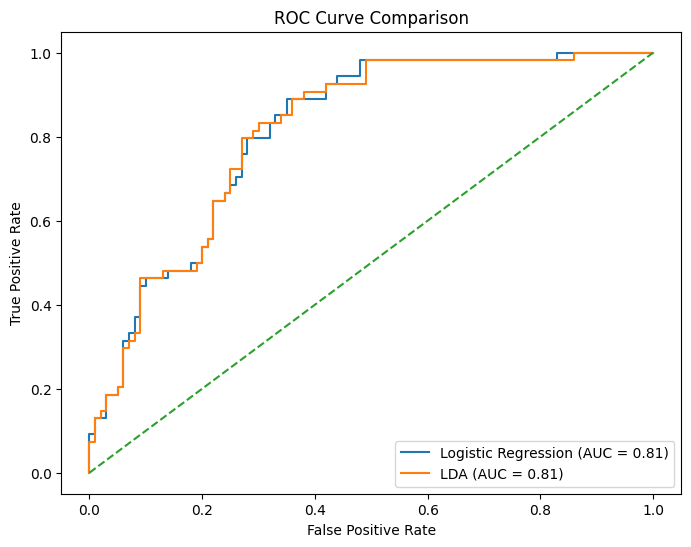

In [25]:
#ROC Curve & AUC Comparison
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#Get presicted robabilities for the positive class (diabetes = 1)
log_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
lda_prob = lda.predict_proba(X_test_scaled)[:, 1]


#Compute ROC curve points
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_prob)

#Compute AUC values
log_auc = roc_auc_score(y_test, log_prob)
lda_auc = roc_auc_score(y_test, lda_prob)

print("Logistic Regression AUC:", log_auc)
print("LDA AUC:", lda_auc)

#plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression (AUC = {:.2f})".format(log_auc))
plt.plot(fpr_lda, tpr_lda, label="LDA (AUC = {:.2f})".format(lda_auc))

#Reference Line for random classifier

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [26]:
#Feature Importance (Logistic Regression)
import pandas as pd
import numpy as np

#Create a datafame of coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

#Add absolute values for ranking
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient', ascending=False
)

feature_importance

,Feature,Coefficient,Abs_Coefficient
1,Glucose,1.182511,1.182511
5,BMI,0.688735,0.688735
0,Pregnancies,0.377502,0.377502
6,DiabetesPedigreeFunction,0.233386,0.233386
7,Age,0.147798,0.147798
4,Insulin,-0.066157,0.066157
2,BloodPressure,-0.044066,0.044066
3,SkinThickness,0.028225,0.028225
